# 01. Data Cleaning, Feature Engineering, and EDA: Manual Dataset

This notebook serves as the initial diagnostic phase of the project. We explore the manually collected historical dataset to identify pricing trends, establish baseline distributions, and engineer the foundational features that will guide our predictive modeling strategy.

## Objectives
- Data Cleaning: Assess data quality, handle duplicate values, and ensure consistent formatting for all manual entries.
- Feature Engineering (Baseline Construction): Derive essential analytical features to support modeling requirements:
  - Label Features: departure_airport, out_inbound, other_airport, airline, airline_code, and is_lcc.
  - Time-based Features: days_to_departure, day_of_week, day_name, is_weekend, and booking_window.
- Exploratory Data Analysis (EDA): Visualize price trends to identify key market patterns (e.g., fare volatility and demand spikes) that will shape our predictive model.

### Environment Setup

In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

from datetime import datetime

In [2]:
# Path to CSV files
source_folder = './1. Manual Dataset - Prices'

# Read the CSV file into a DataFrame
files = [f for f in os.listdir(source_folder) if f.endswith('.csv')]
dataframes = []

for file in files:
    file_path = os.path.join(source_folder,file)
    df = pd.read_csv(file_path)
    route_name = os.path.splitext(file)[0]  # Extract route name from filename
    df['route'] = route_name
    dataframes.append(df)

# Combine all DataFrames into a single DataFrame
df_manual = pd.concat(dataframes, ignore_index=True)

### Data Cleaning and Feature Engineering

In [3]:
# Combine all DataFrames into a single DataFrame
df_manual = pd.concat(dataframes, ignore_index=True)

#### Label Features: departure_airport, out_inbound, airline, airline_code, and is_lcc.

##### Carrier Classification Logic
For historical manual entries where specific airline identifiers were not captured, the following heuristic was applied to derive the is_lcc feature:
- **Default Assumption (Low-Cost Carriers)**: All manual data points were categorized as Low-Cost Carriers (LCC), as these records were specifically filtered to represent the "lowest price available" in the market—a primary characteristic of LCC yield models.
- **Exception Handling (Full-Service Carriers)**: Routes involving London Heathrow (LHR) were explicitly reclassified as Full-Service Carriers (FSC). This classification is grounded in market reality: direct flights from Singapore to London are exclusively serviced by premium, full-service carriers, making the LCC assumption inapplicable for this specific route pair. 

In [4]:
# Standardise route names
df_manual['route'] = df_manual['route'].str.upper().str.strip()

# Create 'departure_airport' and 'out_inbound' to identify if it is an outbound or inbound flight
df_manual['departure_airport'] = df_manual['route'].str.split('-').str[0]
df_manual['out_inbound'] = df_manual['departure_airport'].apply(lambda x: 1 if x == 'SIN' else 2)

# Create 'other_airport' to identify non-SIN airports regardless of origin or destination
df_manual['other_airport'] = df_manual['route'].apply(
    lambda x: x.split('-')[1] if x.split('-')[0] == 'SIN' else x.split('-')[0])

# Add placeholder 'airline' and 'airline_code' column filled with NIL
df_manual['airline'] = 'NIL'
df_manual['airline_code'] = 'NIL'

# Assume the prices of all routes except SIN-LHR vv are serviced by low cost carriers (LCC)
df_manual['is_lcc']=np.where(df_manual['other_airport'] == 'LHR', False, True)

# Labelling manual data extraction rows
df_manual['data_source'] = 'manual'

#### Time-based Features: days_to_departure, day_of_week, day_name, is_weekend, and booking_window.

The search deaprture date for the manual dataset is 6 May 2026.

In [5]:
# Convert the 'Date' column to datetime format
df_manual['Date'] = pd.to_datetime(df_manual['Date'], format='%d/%m/%Y')

# Add 'depature_date' column and convert it to datetime format
df_manual['departure_date']= '06/05/2026'
df_manual['departure_date'] = pd.to_datetime(df_manual['departure_date'], format='%d/%m/%Y')

# Calculate 'days_to_departure' by subtracting the departure date from date column
df_manual['days_to_departure'] = (df_manual['departure_date'] - df_manual['Date']).dt.days

# Add 'day_of_week' and 'day_name' columns to indicate the day in the week
df_manual['day_of_week'] = df_manual['Date'].dt.dayofweek
df_manual['day_name'] = df_manual['Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Add 'is_weekend' column to indicate if the date is a weekend
df_manual['is_weekend'] = df_manual['day_of_week'].isin([4, 5, 6])  # 4 for Friday, 5 for Saturday and 6 for Sunday

# Booking Window logic
lower_bound = ((df_manual['days_to_departure'] - 1) // 14) * 14 + 1
upper_bound = lower_bound + 13

df_manual['booking_window'] = np.where(
    df_manual['days_to_departure'] <= 0, 
    "0 days", 
    lower_bound.astype(str) + "-" + upper_bound.astype(str) + " days"
)

In [6]:
# Convert all column headers to lowercase
df_manual.columns = df_manual.columns.str.strip().str.lower()

In [7]:
# Grouping duplicate rows based on date, route, and departure date to return a single row

df_manual = df_manual.groupby(['date','route','departure_date'], as_index=False).agg({
    'price' : 'mean',
    'days_to_departure' : 'first',
    'day_of_week' : 'first',
    'day_name' : 'first',
    'is_weekend' : 'first',
    'departure_airport' : 'first',
    'out_inbound' : 'first',
    'other_airport' : 'first',
    'data_source' : 'first',
    'booking_window': 'first',
    'airline': 'first',
    'airline_code': 'first',
    'is_lcc': 'first'
})                                                                          

### Exploratory Data Analysis (EDA)

#### Booking Window Analysis: Price Intensity and Day of Week

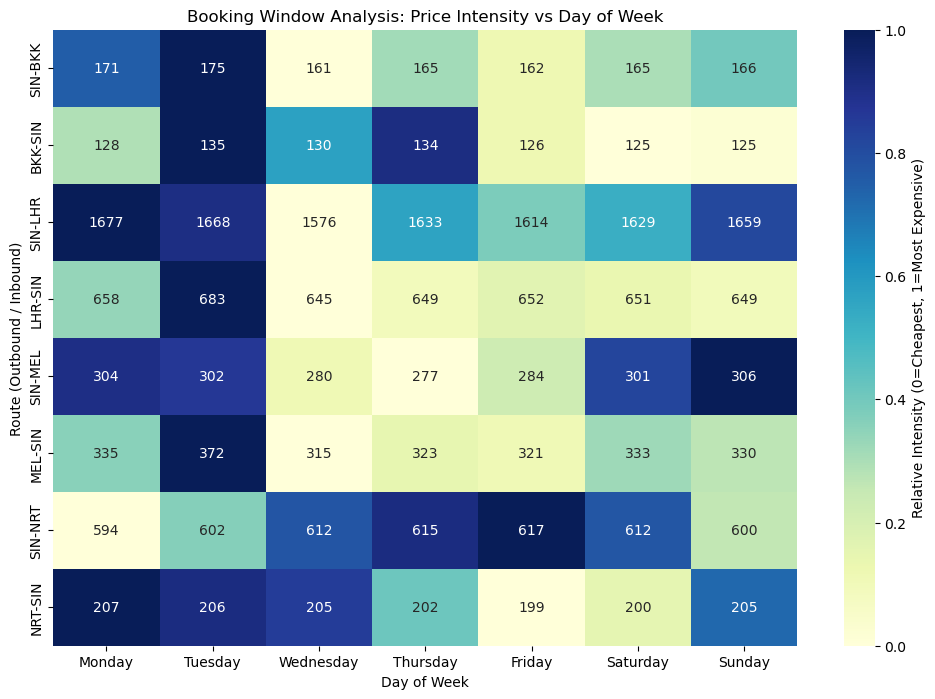

In [8]:
# Sorting routes by airport and ensuring SIN is the first row.
df_manual = df_manual.sort_values(by=['other_airport','out_inbound'])
ordered_routes = df_manual['route'].unique() 

# Pivot data for the heatmap
pivot = df_manual.pivot_table(index='route',
                              columns='day_name',
                              values='price', 
                              aggfunc='mean')

# Reorder columns to sort by route and day
pivot = pivot.reindex(index=ordered_routes, columns=day_order)

# Apply row-level normalisation to see price intensity by route
pivot_norm = pivot.apply(lambda y: (y - y.min()) / (y.max() - y.min()), axis=1)

# Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    data=pivot_norm,     # Use normalized data for the colour
    annot=pivot,          # Use average prices for the TEXT labels
    fmt=".0f",            # Format the numbers (0 decimal places)
    cmap="YlGnBu",        # "Yellow-Green-Blue" color map
    cbar_kws={'label': 'Relative Intensity (0=Cheapest, 1=Most Expensive)'}
)

plt.title("Booking Window Analysis: Price Intensity vs Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Route (Outbound / Inbound)")
plt.show()

#### Analysis
Across the majority of routes, the lowest fare availability was observed when searches were conducted between Wednesday and Friday, with Wednesday being the cheapest. 

Outbound routes from Singapore exhibit a weekend booking premium. Fares were elevated throughout the Saturday to Tuesday window. This likely corresponds to the high-intent search behaviour of leisure travellers planning during their time off. 
SIN-NRT was different, where fares experienced a unique mid-week price volatility, with spikes occuring during the Wednesday 'trough' seen in other markets. 

Searching for a return flight to Singapore on a Tuesday yielded consistently higher price points compared to any other search day.

### Booking Window Analysis: Price Intensity vs. Days to Departure

C:\Users\user\AppData\Local\Temp\ipykernel_12336\1203026914.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_manual.pivot_table(index='route',


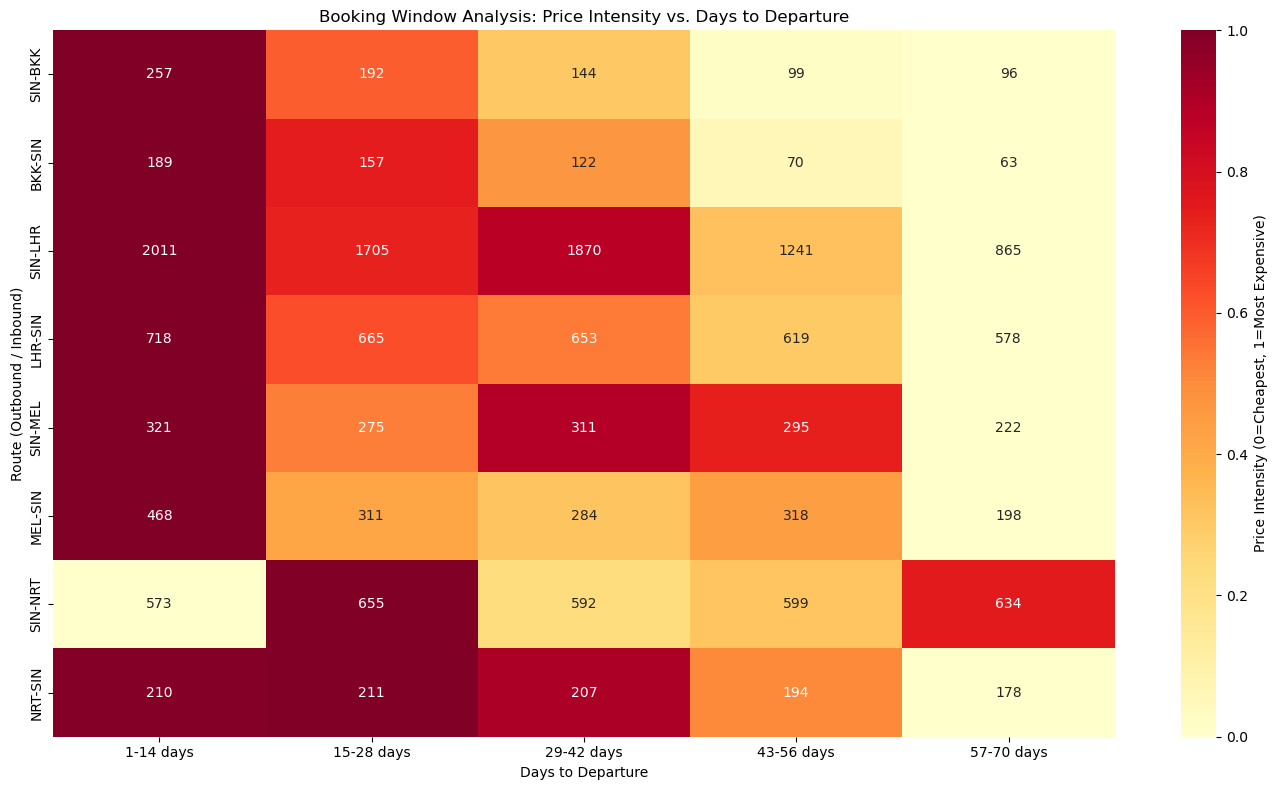

In [9]:
# Days to deapture bins - define time-based bins dynamically for consistent chronological ordering across heatmap visualisation. 
bin_size = 14 
max_days = df_manual['days_to_departure'].max()
bins = np.arange(0, max_days + bin_size, bin_size)
labels = [f"{i+1}-{i+bin_size} days" for i in bins[:-1]]

in_memory_windows = pd.cut(
    df_manual['days_to_departure'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True
)

# Sorting routes by airport and ensuring SIN is the first row.
df_manual = df_manual.sort_values(by=['other_airport', 'out_inbound'])
ordered_routes = df_manual['route'].unique()

# Pivot data for the heatmap
pivot = df_manual.pivot_table(index='route', 
                              columns=in_memory_windows, 
                              values='price', 
                              aggfunc='mean')

# Reorder columns to sort by route
pivot = pivot.reindex(index=ordered_routes)

pivot_norm = pivot.apply(lambda y: (y - y.min()) / (y.max() - y.min()) if (y.max() - y.min()) != 0 else 0, axis=1)

plt.figure(figsize=(14, 8))
sns.heatmap(
    data=pivot_norm, 
    annot=pivot, 
    fmt=".0f", 
    cmap="YlOrRd", # Red usually signifies "Expensive/Urgent" for booking windows
    cbar_kws={'label': 'Price Intensity (0=Cheapest, 1=Most Expensive)'}
)

plt.title("Booking Window Analysis: Price Intensity vs. Days to Departure")
plt.xlabel("Days to Departure")
plt.ylabel("Route (Outbound / Inbound)")
plt.tight_layout()
plt.show()

#### Analysis
The dataset is reflective of a booking curve across most routes, where there is a positive correlation between proximity to departure and airfare cost. Prices peaked significantly within the last 14 days. This validates the industry practice of offering "early bird" fares to secure a baseline load factor before implementing higher yields from price insensitive, late booking travellers. 

Conversely, SIN-NRT deviated from the standard curve, where there is a last minute discounting observed 1-14 days before departure, suggesting a strategic move by carriers to offload 'distressed inventory'. Between the 29-56 day mark, we see the optimal window for early planners. 

### Price Distribution: Price by Route

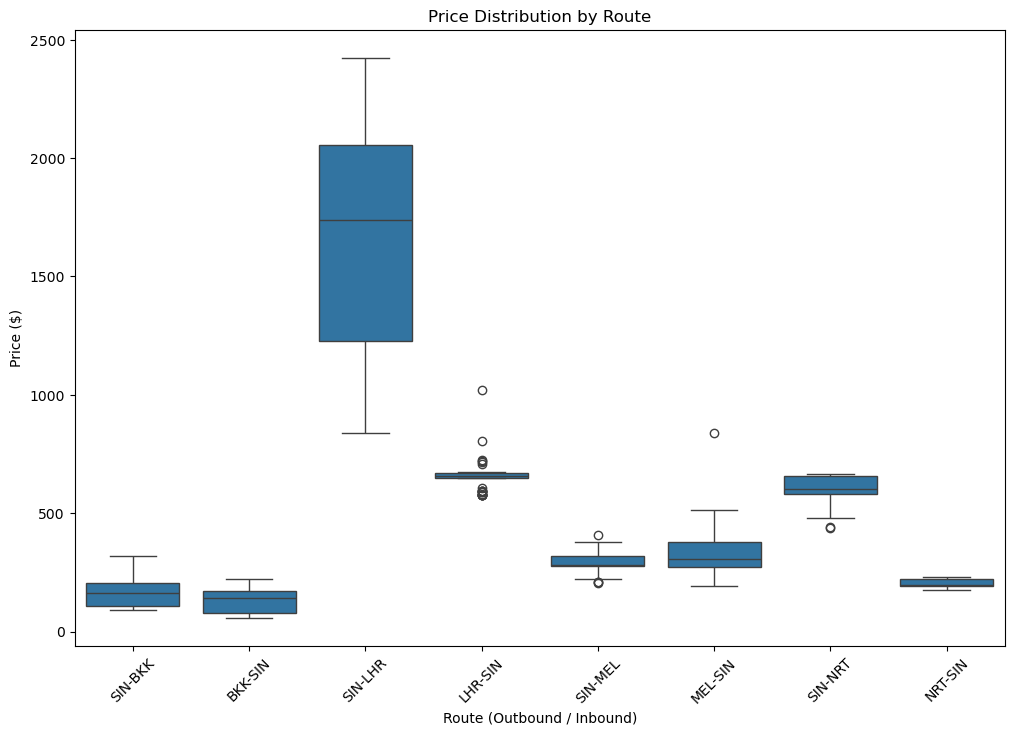

In [10]:
plt.figure(figsize=(12, 8))

# Sorting routes by airport and ensuring SIN is the first row.
sns.boxplot(data=df_manual.sort_values(by=['other_airport','out_inbound']), x='route', y='price')

plt.xticks(rotation=45)
plt.title("Price Distribution by Route")
plt.xlabel("Route (Outbound / Inbound)")
plt.ylabel("Price ($)")
plt.show()

#### Analysis
**SIN-BKK vv**
Mean fares for both legs remain closely aligned. However, outbound fares show a marginally higher ceiling and floor. This suggests a stable, high frequency market where price competition is intense, leaving little room for volatility. 

**SIN-LHR vv**
The SIN-LHR route showed the highest fare dispersion. Prices were particularly volatile, a trend likely exacerbated by external geopolitical factors such as the Middle East conflict. 

**SIN-MEL vv**
A clear directional asymmetry exists in the Melbourne pair, where inbound searches commanded higher prices. This highlights Singapore's role as a critical transit hub for travellers originating in Australia. 

**SIN-NRT vv**
SIN-NRT route showed the most significant price disparity, with outbound fares exceeding inbound fares. This suggests an imbalance in consumer demand. 

*Note: vv represents the round trip.*

### Price Movement: Search Date by Flight Pair

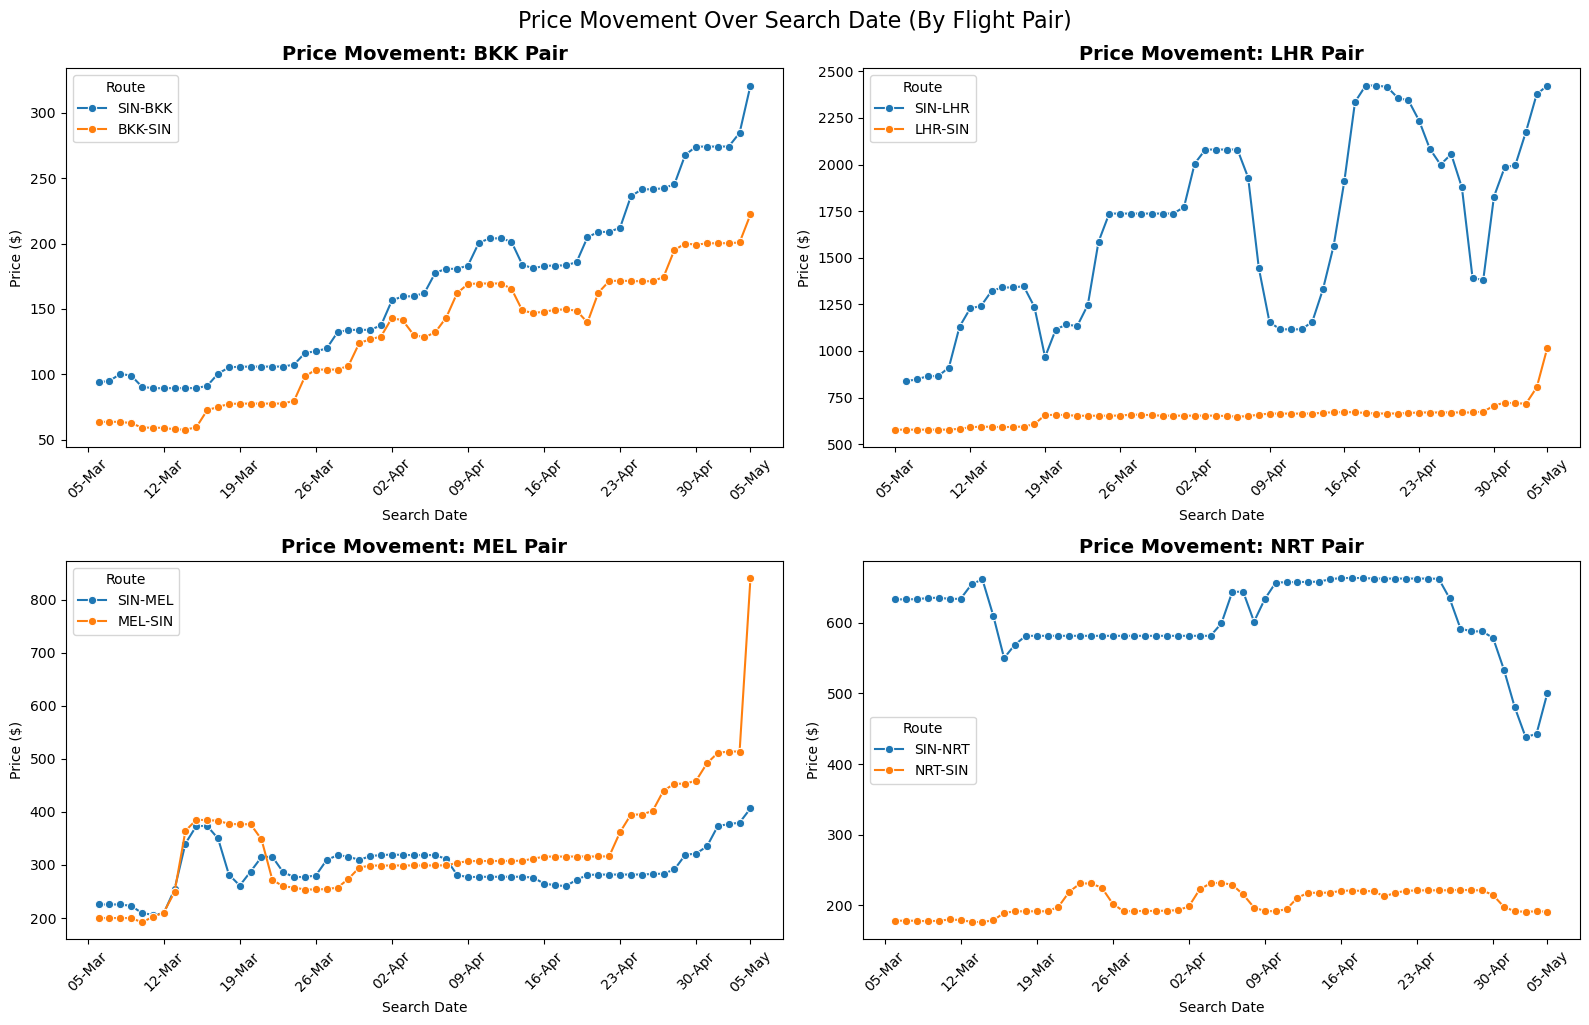

In [11]:
# Plot the Line chart based on the following destinations
destinations = ['BKK', 'LHR', 'MEL', 'NRT']

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
axes = axes.flatten() # Flatten for easy iteration

for i, city in enumerate(destinations):
    # Filter data by flight pair
    city_data = df_manual[df_manual['other_airport'] == city]
    
    # Plot line chart
    sns.lineplot(ax=axes[i], data=city_data, x='date', y='price', hue='route', marker='o')
    
    # Formatting
    axes[i].set_title(f"Price Movement: {city} Pair", fontsize=14, fontweight='bold')
    axes[i].set_ylabel("Price ($)")
    axes[i].set_xlabel("Search Date")
    axes[i].legend(title="Route")
    
    # Plot date labels to show the first and last purchase date, in 7-day intervals 
    min_date = df_manual['date'].min()
    max_date = df_manual['date'].max()
    custom_ticks = pd.date_range(start=min_date, end=max_date, freq='7D').tolist()
    if max_date not in custom_ticks:
        custom_ticks.append(max_date)
    axes[i].set_xticks(custom_ticks)

    # Formatting the date labels
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle("Price Movement Over Search Date (By Flight Pair)", fontsize=16, y=1.02)
plt.show()

### Data Export 

In [12]:
# Export df_manual to CSV
df_manual.to_csv('manualdataset.csv',index=False)